# Simulación — Estimación de Gas con UKF + Regresión Polinomial
### Sensor MOx MQ-136 | ESP32-S3 XIAO | Marco teórico: Bârsan-Langmuir

Pipeline: `R_s → Filtro Mediana (W=7) → R_k → UKF 1D → Ĉ_UKF → PoliReg → C_final`

## 1. Librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model  import LinearRegression
from sklearn.metrics       import mean_squared_error, mean_absolute_error, r2_score

np.random.seed(42)

plt.rcParams.update({
    'figure.dpi':        120,
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.size':         10
})

## 2. Variables globales y parámetros estáticos

In [2]:
# ── Parámetros del sensor MOx (Bârsan-Langmuir) ──────────────────────────────
K_base = 0.06      # Factor pre-exponencial [Ω·ppm^n]
n      = 0.5       # Exponente de la ley de potencias del gas reductor
Ea     = 0.3       # Energía de activación [eV]
kB     = 8.617e-5  # Constante de Boltzmann [eV/K]
Kw     = 0.02      # Afinidad de adsorción de agua
gamma  = 0.5       # Exponente de la isoterma de Langmuir

# ── Condiciones iniciales del UKF ────────────────────────────────────────────
C0 = 0.01  # Concentración inicial: aire limpio sin gas [ppm] — ec. (36) del doc.
P0 = 1.0   # Covarianza inicial: certeza moderada sobre el estado inicial

# ── Parámetros de diseño del UKF (Transformada Unscented) ────────────────────
alpha = 0.001  # Dispersión de puntos sigma — valor pequeño para evitar
               # evaluar concentraciones físicamente imposibles (< 0 ppm)
beta  = 2.0    # Conocimiento previo sobre la distribución del ruido
               # (2 = óptimo para Gaussiana; barrer 0–2 en validación empírica)

# ── Parámetro del filtro de mediana ──────────────────────────────────────────
W = 7  # Ventana impar — cubre 7 muestras consecutivas del ADC

# ── Parámetros de ruido del dataset sintético ────────────────────────────────
SIGMA_RUIDO   = 0.05   # Amplitud del ruido gaussiano: 5% de la media de R_ideal
PROB_IMPULSIVO = 0.02  # Fracción de muestras que reciben un pico impulsivo (2%)
MAG_IMPULSIVO  = 0.50  # Magnitud del pico: ±50% del valor base de R_ideal

## 3. Lectura de datos

In [3]:
# Carga de los datasets generados previamente (9600 baud, 1000 muestras, dt=10.4167 ms)
df_mq = pd.read_csv('dataset_mq136.csv')
df_th = pd.read_csv('dataset_th.csv')

# Arrays de trabajo
t  = df_mq['timestamp_ms'].to_numpy()       # tiempo [ms]
C  = df_mq['concentracion_ppm'].to_numpy()  # concentración verdadera C_true [ppm]
T  = df_th['temperatura_c'].to_numpy()       # temperatura [°C]
RH = df_th['humedad_pct'].to_numpy()         # humedad relativa [%]
T_k = T + 273.15                             # temperatura en Kelvin para el modelo físico

print(f"Muestras cargadas : {len(t)}")
print(f"Rango temporal    : {t[0]:.1f} – {t[-1]:.1f} ms")
print(f"C_true            : {C.min():.2f} – {C.max():.1f} ppm")
print(f"Temperatura       : {T.min():.1f} – {T.max():.1f} °C")
print(f"Humedad           : {RH.min():.1f} – {RH.max():.1f} %RH")

Muestras cargadas : 1000
Rango temporal    : 0.0 – 10406.2 ms
C_true            : 0.50 – 50.0 ppm
Temperatura       : 19.9 – 30.1 °C
Humedad           : 39.8 – 60.4 %RH


## 4. Funciones

In [17]:
def modelo_Rs(C_arr, T_K_arr, RH_arr):
    """
    Modelo fenomenológico de Bârsan-Langmuir — ec. (6) del marco teórico.
    Calcula la resistencia teórica del sensor dado el estado del gas y el entorno.
    Rs = K_base · C^(-n) · exp(Ea / kB·T) · (1 + Kw·RH)^(-gamma)
    """
    C_safe = np.maximum(C_arr, C0)  # evita división por cero en C^(-n)
    return K_base * C_safe**(-n) * np.exp(Ea / (kB * T_K_arr)) * (1 + Kw * RH_arr)**(-gamma)


def despeje_analitico(Rs_arr, T_K_arr, RH_arr):
    """
    Inversión del modelo fenomenológico — despeja C a partir de Rs, T y RH.
    C = (Rs / factor_TH)^(-1/n)  donde  factor_TH = K_base · exp(Ea/kBT) · (1+Kw·RH)^(-gamma)

    Nota: el paréntesis sobre la división completa es crítico; sin él Python
    aplica la potencia solo al denominador.
    """
    factor_TH = K_base * np.exp(Ea / (kB * T_K_arr)) * (1 + Kw * RH_arr)**(-gamma)
    return (Rs_arr / factor_TH)**(-1.0 / n)


def filtro_mediana(Rs_arr, ventana):
    """
    Filtro de mediana móvil causal (min_periods=1) sobre la señal de resistencia.
    Replica el búfer circular del firmware: nunca mira muestras futuras.
    Entrada:  Rs_arr — resistencia cruda del ADC [Ω]
    Salida:   R_k    — resistencia limpia para el UKF [Ω]
    """
    return pd.Series(Rs_arr).rolling(window=ventana, center=False, min_periods=1).median().to_numpy()


def calcular_pesos_ukf(alpha, beta):
    """
    Calcula los pesos estáticos del UKF para L=1 (sistema unidimensional).
    Ecuaciones (37)-(39) del marco teórico.
    Estos pesos se calculan UNA SOLA VEZ antes del bucle principal.
    """
    # Wm0: peso de la media para el punto central
    Wm0 = (3*alpha**2 - 1) / (3*alpha**2)
    # Wc0: peso de la covarianza para el punto central (agrega beta)
    Wc0 = Wm0 + (1 - alpha**2 + beta)
    # Wmi = Wci: pesos de los puntos laterales (iguales para media y covarianza)
    Wmi = 1.0 / (6*alpha**2)
    return Wm0, Wc0, Wmi


def correr_ukf(R_k_arr, T_K_arr, RH_arr, Q_val, N_val,
               alpha, beta, C_init=0.01, P_init=1.0):
    """
    UKF 1D en espacio logarítmico — resuelve el problema de escala entre
    el estado (ppm) y la medición (Ω).

    Estado:    x = log(C)       → se convierte a C = exp(x) al salir
    Medición:  z = log(R_k)     → adimensional, misma escala que el estado
    Innovación: y_tilde = log(R_k) - log(Z_pred)  → debe tender a 0
    """
    Wm0, Wc0, Wmi = calcular_pesos_ukf(alpha, beta)

    # Estado inicial en log-space
    x_est = np.log(C_init)
    P_est = P_init

    n_muestras = len(R_k_arr)
    C_ukf   = np.zeros(n_muestras)
    y_tilde = np.zeros(n_muestras)

    for k in range(n_muestras):
        # ── Etapa 1: Puntos sigma en log(C) (ec. 23-25) ───────────────────
        spread = np.sqrt(3 * alpha**2 * P_est)
        chi_0  = x_est
        chi_1  = x_est + spread
        chi_2  = x_est - spread

        # ── Etapa 2: Predicción — random walk en log-space (ec. 26-27) ────
        x_pred = Wm0*chi_0 + Wmi*chi_1 + Wmi*chi_2
        P_pred = Wc0*(chi_0-x_pred)**2 + Wmi*(chi_1-x_pred)**2 + Wmi*(chi_2-x_pred)**2 + Q_val

        # ── Etapa 3: Proyectar sigma points → log(Rs) (ec. 28) ────────────
        # Convertimos cada punto sigma a C (ppm), aplicamos el modelo físico
        # y tomamos el logaritmo — así medición y estado quedan en la misma escala
        Tk  = T_K_arr[k]
        RHk = RH_arr[k]
        Z0  = np.log(modelo_Rs(np.exp(chi_0), Tk, RHk))
        Z1  = np.log(modelo_Rs(np.exp(chi_1), Tk, RHk))
        Z2  = np.log(modelo_Rs(np.exp(chi_2), Tk, RHk))
        Z_pred = Wm0*Z0 + Wmi*Z1 + Wmi*Z2   # log(Rs) predicho (ec. 29)

        # ── Etapa 4: Actualización con log(R_k) (ec. 30-34) ───────────────
        Pzz = Wc0*(Z0-Z_pred)**2 + Wmi*(Z1-Z_pred)**2 + Wmi*(Z2-Z_pred)**2 + N_val
        Pxz = Wc0*(chi_0-x_pred)*(Z0-Z_pred) + Wmi*(chi_1-x_pred)*(Z1-Z_pred) + Wmi*(chi_2-x_pred)*(Z2-Z_pred)
        K_g = Pxz / Pzz

        innov  = np.log(R_k_arr[k]) - Z_pred  # innovación en log-space
        x_est  = x_pred + K_g * innov
        P_est  = P_pred - K_g**2 * Pzz

        if P_est < 0:
            print(f"k={k}: P_est negativo ({P_est:.6f}), Q={Q_val}")
            break

        C_ukf[k]   = np.exp(x_est)  # convertir de vuelta a ppm
        y_tilde[k] = innov           # adimensional, debe tender a 0
    
    return C_ukf, y_tilde

def ajustar_polireg(C_entrada, T_arr, RH_arr, C_target):
    """
    Entrena la regresión polinomial multivariable de grado 2 — ec. (35) del marco teórico.
    Features: [C, T, RH, C², C·T, C·RH, T², T·RH, RH²]
    Entrada:  C_entrada — estimación de concentración como feature principal
              C_target  — concentración verdadera (target de entrenamiento)
    Salida:   C_final   — concentración compensada [ppm]
              modelo    — modelo entrenado (coeficientes exportables al firmware)
              poly      — transformador para reutilizar el mismo pipeline
    """
    X = np.column_stack((C_entrada, T_arr, RH_arr))
    poly   = PolynomialFeatures(degree=2, include_bias=False)
    X_poly = poly.fit_transform(X)
    modelo = LinearRegression().fit(X_poly, C_target)
    C_final = modelo.predict(X_poly)
    return C_final, modelo, poly

## 5. Verificación del modelo físico

Antes de sintetizar el dataset, confirmamos que `K_base`, `n`, `Ea`, `Kw` y `gamma` producen un rango de resistencias con sentido físico para el divisor de tensión del ESP32-S3.

In [18]:
print("R_ideal vs concentración (T=25°C, RH=50%):")
print(f"{'C [ppm]':>10s}  {'R_ideal [Ω]':>14s}")
print("-" * 28)
for C_test in [0.01, 0.5, 5.0, 10.0, 25.0, 50.0]:
    Rs = modelo_Rs(np.array([C_test]), np.array([298.15]), np.array([50.0]))[0]
    print(f"{C_test:>10.2f}  {Rs:>14.2f}")

R_ideal vs concentración (T=25°C, RH=50%):
   C [ppm]     R_ideal [Ω]
----------------------------
      0.01        49989.87
      0.50         7069.64
      5.00         2235.62
     10.00         1580.82
     25.00          999.80
     50.00          706.96


## 6. Síntesis del dataset (señal empírica simulada)

In [19]:
# ── Señal ideal (sin ruido) ───────────────────────────────────────────────────
R_ideal = modelo_Rs(C, T_k, RH)

# ── Ruido gaussiano proporcional a la señal ───────────────────────────────────
sigma_ruido    = SIGMA_RUIDO * np.mean(R_ideal)
ruido_gauss    = np.random.normal(0, sigma_ruido, size=len(R_ideal))

# ── Ruido impulsivo (picos del 2% de las muestras) ───────────────────────────
ruido_impuls   = np.zeros(len(R_ideal))
idx_picos      = np.random.choice(len(R_ideal), size=int(PROB_IMPULSIVO*len(R_ideal)), replace=False)
ruido_impuls[idx_picos] = np.random.uniform(
    -MAG_IMPULSIVO * np.mean(R_ideal),
     MAG_IMPULSIVO * np.mean(R_ideal),
    size=len(idx_picos)
)

# ── Señal empírica total (lo que leería el ADC del ESP32) ─────────────────────
R_s = R_ideal + ruido_gauss + ruido_impuls

print(f"R_ideal: {R_ideal.min():.2f} – {R_ideal.max():.2f} Ω")
print(f"R_s    : {R_s.min():.2f} – {R_s.max():.2f} Ω  (con ruido)")
print(f"Picos inyectados: {len(idx_picos)} muestras ({PROB_IMPULSIVO*100:.0f}%)")

R_ideal: 788.34 – 6738.76 Ω
R_s    : -558.77 – 7411.70 Ω  (con ruido)
Picos inyectados: 20 muestras (2%)


## 7. Filtro de mediana móvil (W=7)

Aplica el búfer circular sobre `R_s` para obtener `R_k`, la resistencia limpia que entra al UKF.

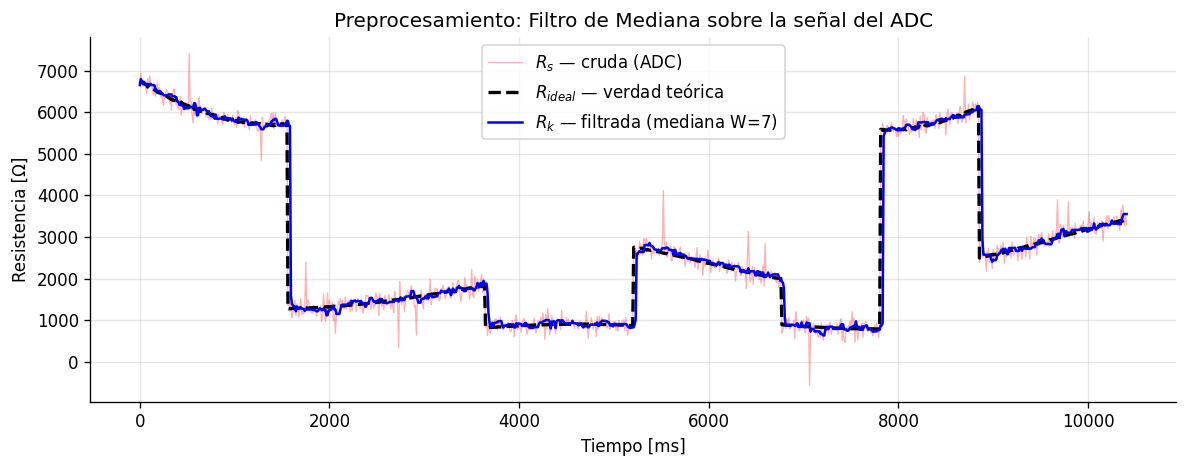

In [20]:
R_k = filtro_mediana(R_s, W)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t, R_s,     color='red',   alpha=0.3,  linewidth=0.8, label='$R_s$ — cruda (ADC)')
ax.plot(t, R_ideal, color='black', linestyle='--', linewidth=2, label='$R_{ideal}$ — verdad teórica')
ax.plot(t, R_k,     color='blue',  linewidth=1.5, label=f'$R_k$ — filtrada (mediana W={W})')
ax.set_ylabel('Resistencia [Ω]')
ax.set_xlabel('Tiempo [ms]')
ax.set_title('Preprocesamiento: Filtro de Mediana sobre la señal del ADC')
ax.legend()
plt.tight_layout()
plt.show()

## 8. Despeje analítico de C

Invierte el modelo fenomenológico sobre `R_k` para obtener `C_raw` — el baseline sin filtro estocástico.

In [21]:
# Despeje analítico sobre la señal filtrada (R_k)
C_raw = despeje_analitico(R_k, T_k, RH)

## 9. Cálculo de N (ruido de medición)

`N = Var(R_s)` en la ventana de "aire limpio simulado" — segmento donde `C_true` permanece
constante en el nivel base, antes del primer escalón de gas. Equivalente a la cámara controlada
que pide el documento (sección 2.1).

In [22]:
# Máscara del tramo sin gas (nivel base, antes del primer escalón)
mask_limpio = (C <= 0.5 + 1e-6)

# N en log-space: Var(log(R_s) - log(R_ideal)) en el tramo de aire limpio
# Resultado adimensional ~1e-3, compatible con el estado x = log(C)
N = np.var(np.log(R_s[mask_limpio]) - np.log(R_ideal[mask_limpio]))

print(f"Muestras de 'aire limpio' usadas: {mask_limpio.sum()} de {len(C)}")
print(f"N (varianza log-space)           = {N:.6f}  (adimensional)")

Muestras de 'aire limpio' usadas: 250 de 1000
N (varianza log-space)           = 0.000874  (adimensional)


## 10. Sintonización de Q (ruido de proceso) — barrido empírico

Q se determina empíricamente (sección 2.1 del documento): se barre un rango y se elige
el valor que minimiza el RMSE contra `C_true`. Mismo `alpha` y `beta` que usará el UKF final.

Q =  0.00001  →  RMSE = 21.5034 ppm
Q =  0.00010  →  RMSE = 21.5034 ppm
Q =  0.00100  →  RMSE = 6.4585 ppm
Q =  0.01000  →  RMSE = 4.6385 ppm
Q =  0.05000  →  RMSE = 5.5578 ppm
Q =  0.10000  →  RMSE = 4.6290 ppm
Q =  0.50000  →  RMSE = 21.5036 ppm
Q =  1.00000  →  RMSE = 14.0448 ppm
Q =  2.00000  →  RMSE = 21.5038 ppm
Q =  3.00000  →  RMSE = 5.5523 ppm
Q =  4.00000  →  RMSE = 21.5052 ppm
Q =  5.00000  →  RMSE = 21.5039 ppm
Q =  6.00000  →  RMSE = 21.4770 ppm
Q =  7.00000  →  RMSE = 20.0267 ppm
Q =  8.00000  →  RMSE = 19.9876 ppm
Q =  9.00000  →  RMSE = 21.5041 ppm
Q = 10.00000  →  RMSE = 20.0143 ppm

Q óptimo seleccionado: 0.1


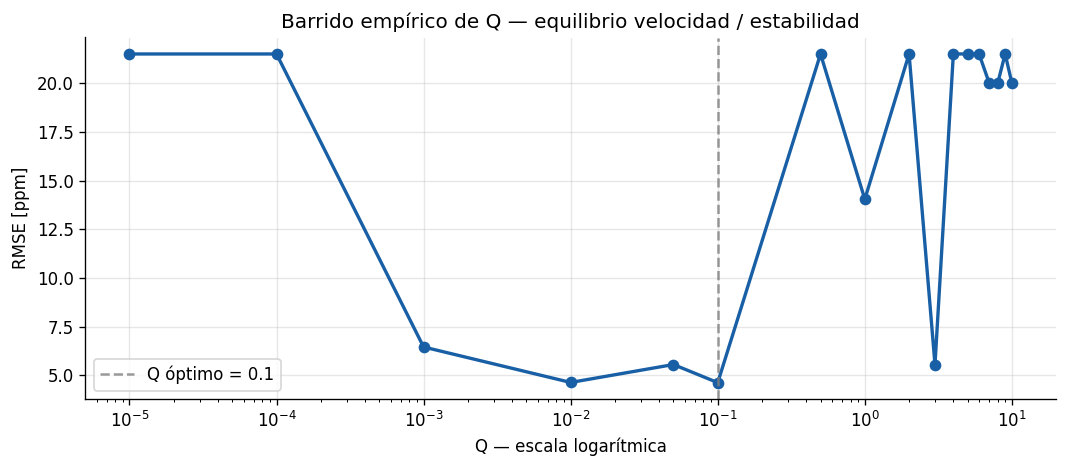

In [40]:
Q_candidatos = [ 1e-5, 1e-4, 1e-3, 0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]
rmse_Q = []

for Q_test in Q_candidatos:
    C_tmp, _ = correr_ukf(R_k, T_k, RH, Q_test, N, alpha=alpha, beta=beta)
    rmse_Q.append(np.sqrt(np.mean((C_tmp - C)**2)))
    print(f"Q = {Q_test:8.5f}  →  RMSE = {rmse_Q[-1]:.4f} ppm")

Q = Q_candidatos[np.argmin(rmse_Q)]
print(f"\nQ óptimo seleccionado: {Q}")

fig, ax = plt.subplots(figsize=(9, 4))
ax.semilogx(Q_candidatos, rmse_Q, 'o-', color='#185FA5', linewidth=2)
ax.axvline(Q, color='gray', linestyle='--', alpha=0.8, label=f'Q óptimo = {Q}')
ax.set_xlabel('Q — escala logarítmica')
ax.set_ylabel('RMSE [ppm]')
ax.set_title('Barrido empírico de Q — equilibrio velocidad / estabilidad')
ax.legend()
plt.tight_layout()
plt.show()

## 11. Test unitario — verificación contra la traza manual del documento

Reproduce los valores calculados a mano en las ecuaciones (42)-(44) y (37)-(39) para k=1.
Confirma que la implementación es exactamente fiel al marco teórico antes de correr las 1000 muestras.

In [24]:
# Verificación de puntos sigma (ec. 42-44): C0=0.01, P0=1, alpha=0.001
spread_test = np.sqrt(3 * 0.001**2 * 1.0)
chi_0_test  = 0.01
chi_1_test  = 0.01 + spread_test
chi_2_test  = 0.01 - spread_test

print("Puntos sigma (ec. 42-44):")
print(f"  chi_0 = {chi_0_test:.6f}   (esperado: 0.010000)")
print(f"  chi_1 = {chi_1_test:.6f}   (esperado: 0.011732)")
print(f"  chi_2 = {chi_2_test:.6f}   (esperado: 0.008268)")
assert abs(chi_1_test - 0.011732) < 1e-5, "chi_1 no coincide"
assert abs(chi_2_test - 0.008268) < 1e-5, "chi_2 no coincide"

# Verificación de pesos (ec. 37-39)
Wm0_t, Wc0_t, Wmi_t = calcular_pesos_ukf(0.001, 2.0)
print(f"\nPesos (ec. 37-39):")
print(f"  Wm0 = {Wm0_t:,.2f}   (esperado: ≈ -333332.33)")
print(f"  Wc0 = {Wc0_t:,.2f}   (esperado: ≈ -333329.33)")
print(f"  Wmi = {Wmi_t:,.2f}   (esperado: ≈  166666.66)")

assert abs(Wm0_t - (-333332.33)) < 1.0, "Wm0 no coincide"

print("\n✓ Implementación verificada contra el documento.")

Puntos sigma (ec. 42-44):
  chi_0 = 0.010000   (esperado: 0.010000)
  chi_1 = 0.011732   (esperado: 0.011732)
  chi_2 = 0.008268   (esperado: 0.008268)

Pesos (ec. 37-39):
  Wm0 = -333,332.33   (esperado: ≈ -333332.33)
  Wc0 = -333,329.33   (esperado: ≈ -333329.33)
  Wmi = 166,666.67   (esperado: ≈  166666.66)

✓ Implementación verificada contra el documento.


## 12. UKF 1D

Ejecuta el filtro completo sobre las 1000 muestras usando `Q` y `N` calibrados.

RMSE despeje analítico : 4.6306 ppm
RMSE UKF               : 4.6290 ppm


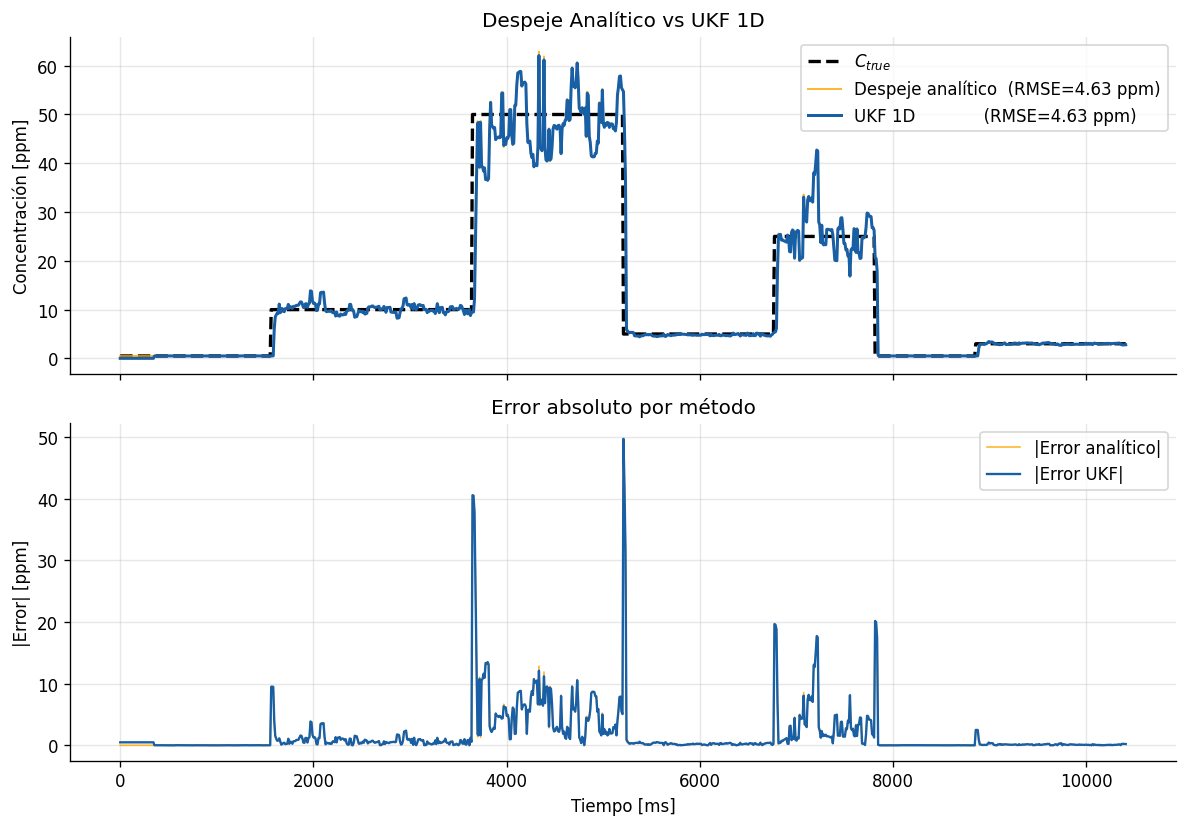

In [41]:
C_ukf, y_tilde = correr_ukf(R_k, T_k, RH, Q, N, alpha=alpha, beta=beta)

rmse_raw = np.sqrt(np.mean((C_raw - C)**2))
rmse_ukf = np.sqrt(np.mean((C_ukf - C)**2))
print(f"RMSE despeje analítico : {rmse_raw:.4f} ppm")
print(f"RMSE UKF               : {rmse_ukf:.4f} ppm")

# ── Comparativa: despeje analítico vs UKF ────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

# Panel superior: señales completas
axes[0].plot(t, C,       color='black',   linewidth=2,   linestyle='--', label='$C_{true}$')
axes[0].plot(t, C_raw,   color='orange',  linewidth=1.2, alpha=0.8,      label=f'Despeje analítico  (RMSE={rmse_raw:.2f} ppm)')
axes[0].plot(t, C_ukf,   color='#185FA5', linewidth=1.8,                  label=f'UKF 1D             (RMSE={rmse_ukf:.2f} ppm)')
axes[0].set_ylabel('Concentración [ppm]')
axes[0].set_title('Despeje Analítico vs UKF 1D')
axes[0].legend()

# Panel inferior: error absoluto de cada método
axes[1].plot(t, np.abs(C_raw - C), color='orange',  linewidth=1.0, alpha=0.8, label='|Error analítico|')
axes[1].plot(t, np.abs(C_ukf - C), color='#185FA5', linewidth=1.4,             label='|Error UKF|')
axes[1].set_ylabel('|Error| [ppm]')
axes[1].set_xlabel('Tiempo [ms]')
axes[1].set_title('Error absoluto por método')
axes[1].legend()

plt.tight_layout()
plt.show()

RMSE despeje analítico : 4.6306 ppm
RMSE UKF               : 4.6385 ppm


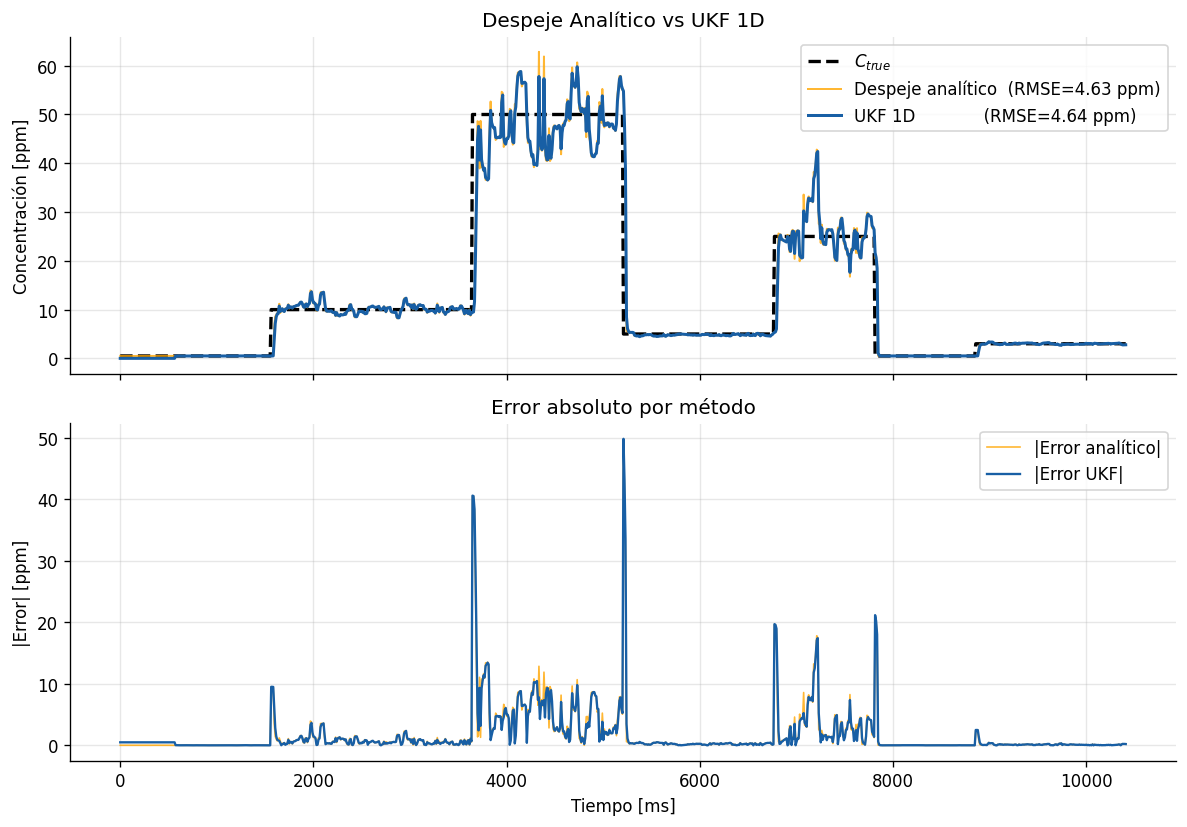

In [42]:
C_ukf2, y_tilde2 = correr_ukf(R_k, T_k, RH, 0.01, N, alpha=alpha, beta=beta)

rmse_raw = np.sqrt(np.mean((C_raw - C)**2))
rmse_ukf = np.sqrt(np.mean((C_ukf2 - C)**2))
print(f"RMSE despeje analítico : {rmse_raw:.4f} ppm")
print(f"RMSE UKF               : {rmse_ukf:.4f} ppm")

# ── Comparativa: despeje analítico vs UKF ────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

# Panel superior: señales completas
axes[0].plot(t, C,       color='black',   linewidth=2,   linestyle='--', label='$C_{true}$')
axes[0].plot(t, C_raw,   color='orange',  linewidth=1.2, alpha=0.8,      label=f'Despeje analítico  (RMSE={rmse_raw:.2f} ppm)')
axes[0].plot(t, C_ukf2,   color='#185FA5', linewidth=1.8,                  label=f'UKF 1D             (RMSE={rmse_ukf:.2f} ppm)')
axes[0].set_ylabel('Concentración [ppm]')
axes[0].set_title('Despeje Analítico vs UKF 1D')
axes[0].legend()

# Panel inferior: error absoluto de cada método
axes[1].plot(t, np.abs(C_raw - C), color='orange',  linewidth=1.0, alpha=0.8, label='|Error analítico|')
axes[1].plot(t, np.abs(C_ukf2 - C), color='#185FA5', linewidth=1.4,             label='|Error UKF|')
axes[1].set_ylabel('|Error| [ppm]')
axes[1].set_xlabel('Tiempo [ms]')
axes[1].set_title('Error absoluto por método')
axes[1].legend()

plt.tight_layout()
plt.show()

## 13. Regresión Polinomial sobre UKF (pipeline completo)

Entrena el modelo OLS usando `Ĉ_UKF` como feature principal — ecuación (35) del documento.

RMSE UKF + PoliReg : 3.6894 ppm
R²   UKF + PoliReg : 0.9523

Coeficientes del modelo (exportar al firmware):
  w0 (bias) = 24.096715
  C_ukf        = 3.799088
  T            = -3.969458
  RH           = 0.647627
  C_ukf^2      = -0.021446
  C_ukf T      = 0.014481
  C_ukf RH     = -0.047535
  T^2          = -0.050392
  T RH         = 0.119939
  RH^2         = -0.031471


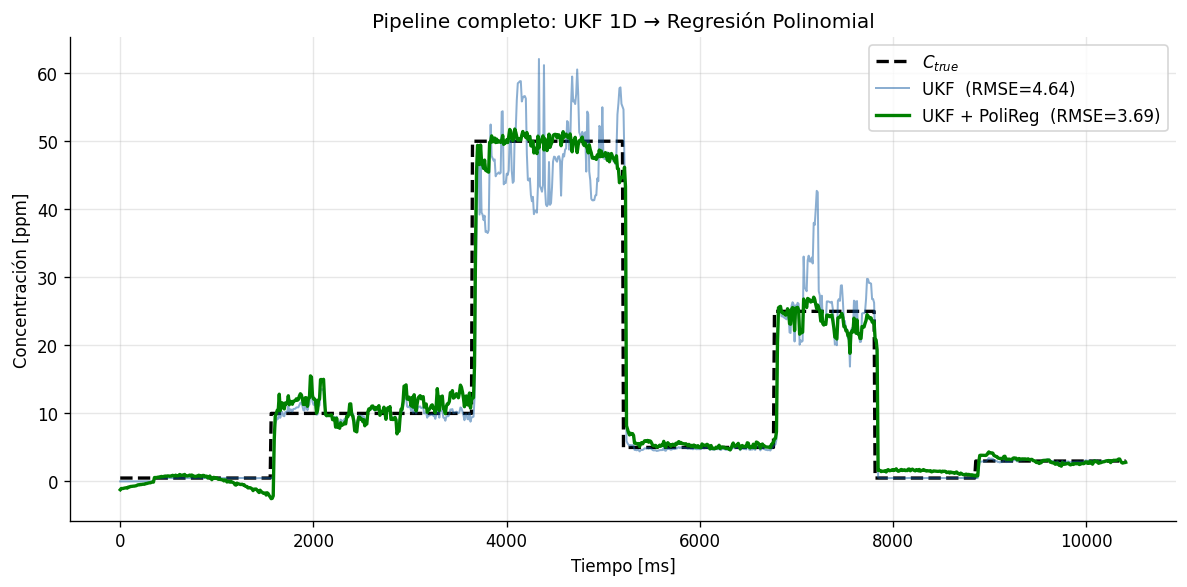

In [28]:
C_ukf_poly, modelo_ukf, poly_ukf = ajustar_polireg(C_ukf, T, RH, C)

rmse_ukf_poly = np.sqrt(np.mean((C_ukf_poly - C)**2))
r2_ukf_poly   = r2_score(C, C_ukf_poly)
print(f"RMSE UKF + PoliReg : {rmse_ukf_poly:.4f} ppm")
print(f"R²   UKF + PoliReg : {r2_ukf_poly:.4f}")

print("\nCoeficientes del modelo (exportar al firmware):")
print(f"  w0 (bias) = {modelo_ukf.intercept_:.6f}")
for nombre, coef in zip(poly_ukf.get_feature_names_out(['C_ukf','T','RH']), modelo_ukf.coef_):
    print(f"  {nombre:12s} = {coef:.6f}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(t, C,           color='black',   linewidth=2,   linestyle='--', label='$C_{true}$')
ax.plot(t, C_ukf,       color='#185FA5', linewidth=1.2, alpha=0.5,      label=f'UKF  (RMSE={rmse_ukf:.2f})')
ax.plot(t, C_ukf_poly,  color='green',   linewidth=2.0,                  label=f'UKF + PoliReg  (RMSE={rmse_ukf_poly:.2f})')
ax.set_ylabel('Concentración [ppm]')
ax.set_xlabel('Tiempo [ms]')
ax.set_title('Pipeline completo: UKF 1D → Regresión Polinomial')
ax.legend()
plt.tight_layout()
plt.show()

## 14. Experimento de control — PoliReg sin UKF

Misma regresión pero alimentada directamente con `C_raw` (despeje analítico + mediana), sin pasar por el UKF. Permite aislar si la mejora viene de la combinación o solo de la PoliReg.

RMSE PoliReg sin UKF : 3.6773 ppm
R²   PoliReg sin UKF : 0.9526


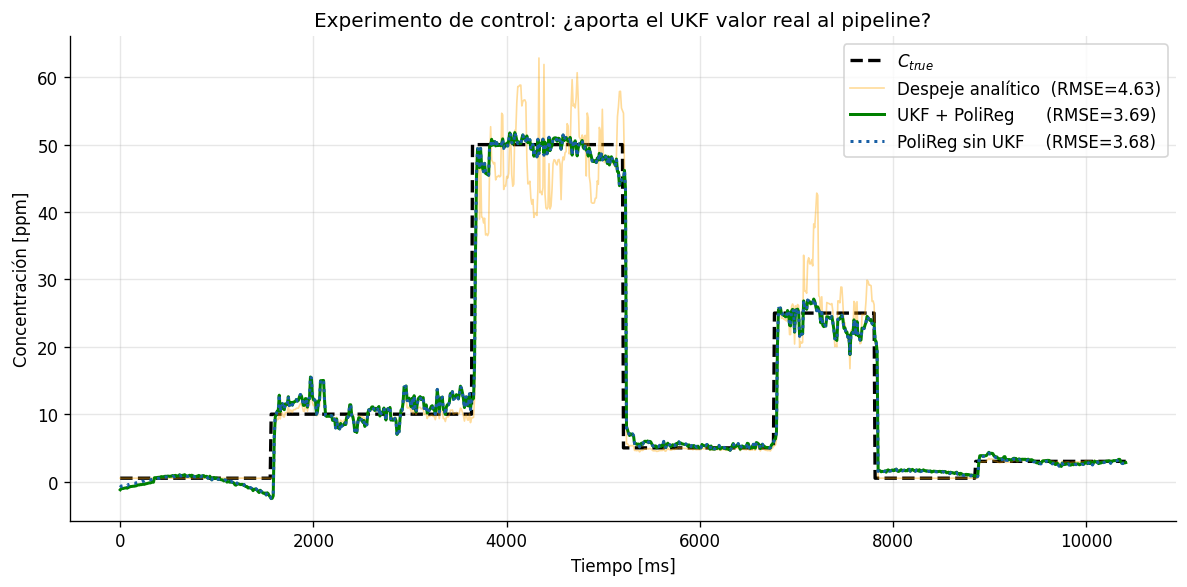

In [29]:
C_raw_poly, modelo_raw, poly_raw = ajustar_polireg(C_raw, T, RH, C)

rmse_raw_poly = np.sqrt(np.mean((C_raw_poly - C)**2))
r2_raw_poly   = r2_score(C, C_raw_poly)
print(f"RMSE PoliReg sin UKF : {rmse_raw_poly:.4f} ppm")
print(f"R²   PoliReg sin UKF : {r2_raw_poly:.4f}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(t, C,           color='black',   linewidth=2,   linestyle='--', label='$C_{true}$')
ax.plot(t, C_raw,       color='orange',  linewidth=1.0, alpha=0.4,      label=f'Despeje analítico  (RMSE={rmse_raw:.2f})')
ax.plot(t, C_ukf_poly,  color='green',   linewidth=1.8,                  label=f'UKF + PoliReg      (RMSE={rmse_ukf_poly:.2f})')
ax.plot(t, C_raw_poly,  color='#185FA5', linewidth=1.8, linestyle=':',   label=f'PoliReg sin UKF    (RMSE={rmse_raw_poly:.2f})')
ax.set_ylabel('Concentración [ppm]')
ax.set_xlabel('Tiempo [ms]')
ax.set_title('Experimento de control: ¿aporta el UKF valor real al pipeline?')
ax.legend()
plt.tight_layout()
plt.show()

## 15. Métricas finales y diagnóstico estocástico

Método                                 RMSE [ppm]     MAE [ppm]        R²
---------------------------------------------------------------------------
Despeje analítico (C_raw)                  4.6306        1.7462    0.9248
Solo UKF (C_ukf)                           4.6290        1.7557    0.9248
UKF + PoliReg                              3.6894        1.3988    0.9523
PoliReg sin UKF (control)                  3.6773        1.3742    0.9526

───────────────────────────────────────────────────────────────────────────
Diagnóstico UKF — Secuencia de innovación y_tilde:
  Media    = 0.1867   (debe tender a 0 si el filtro es óptimo)
  Varianza = 26.8035
  σ        = 5.1772


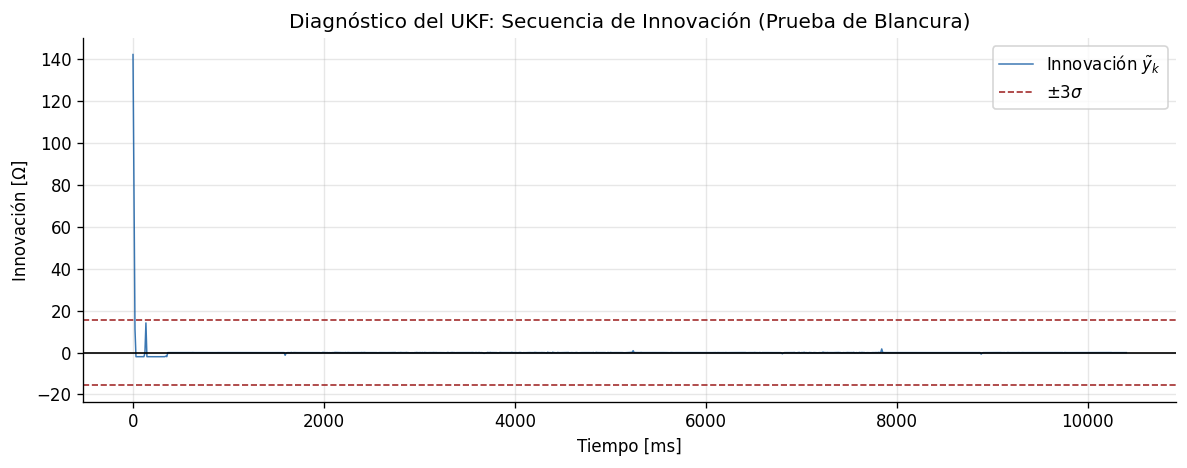

In [30]:
# ── A. Tabla comparativa de todos los métodos ────────────────────────────────
resultados = {
    'Despeje analítico (C_raw)':     C_raw,
    'Solo UKF (C_ukf)':              C_ukf,
    'UKF + PoliReg':                 C_ukf_poly,
    'PoliReg sin UKF (control)':     C_raw_poly,
}

print(f"{'Método':35s}  {'RMSE [ppm]':>12s}  {'MAE [ppm]':>12s}  {'R²':>8s}")
print("-" * 75)
for nombre, est in resultados.items():
    rmse = np.sqrt(mean_squared_error(C, est))
    mae  = mean_absolute_error(C, est)
    r2   = r2_score(C, est)
    print(f"{nombre:35s}  {rmse:12.4f}  {mae:12.4f}  {r2:8.4f}")

# ── B. Diagnóstico de blancura (Whiteness Test) ───────────────────────────────
media_y   = np.mean(y_tilde)
sigma_y   = np.std(y_tilde)

print(f"\n{'─'*75}")
print(f"Diagnóstico UKF — Secuencia de innovación y_tilde:")
print(f"  Media    = {media_y:.4f}   (debe tender a 0 si el filtro es óptimo)")
print(f"  Varianza = {np.var(y_tilde):.4f}")
print(f"  σ        = {sigma_y:.4f}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t, y_tilde, color='#185FA5', linewidth=0.9, alpha=0.85, label=r'Innovación $\tilde{y}_k$')
ax.axhline(0,              color='black',   linewidth=1.0, linestyle='-')
ax.axhline( 3*sigma_y,     color='#A32D2D', linewidth=1.0, linestyle='--', label=r'$\pm 3\sigma$')
ax.axhline(-3*sigma_y,     color='#A32D2D', linewidth=1.0, linestyle='--')
ax.set_ylabel('Innovación [Ω]')
ax.set_xlabel('Tiempo [ms]')
ax.set_title('Diagnóstico del UKF: Secuencia de Innovación (Prueba de Blancura)')
ax.legend()
plt.tight_layout()
plt.show()

Considerar el uso de la combinacion lineal de PoliReg como funcion de medicion para UKF.
Aplicar logaritmo en h(C,T,RH)

A